# Installation Requirnments


In [282]:
! pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit jupyter ipython



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing libraries

In [371]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score
)
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


import joblib
import pickle
import requests
import json
import streamlit as st

print( "Importing Libraries Done")

Importing Libraries Done


## Data Cleaning & Understanding 

In [284]:
def load_dataset(file_path):
    
    print(f"Loading dataset from: {file_path}")
    df = pd.read_csv(file_path)
    print(f" Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df
df=load_dataset(r"F:\Ai graduation project\data.csv")

Loading dataset from: F:\Ai graduation project\data.csv
 Dataset loaded: 4600 rows, 18 columns


In [285]:
def display_data_summary(df):
    
    print("\n" + "="*60)
    print("DATA SUMMARY REPORT")
    print("="*60)
    
    summary = {
        'shape': df.shape, # Shape of the data (4600*18)
        'columns': df.columns.tolist(), # names of columns
        'dtypes': df.dtypes.to_dict(), #data types of columns
        'missing_values': df.isnull().sum().to_dict(), # check the missing values
        'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2).to_dict(), # to get percentage
        'duplicates': df.duplicated().sum(),
    }
    
    print(f" Shape: {summary['shape']}")
    print(f" Numeric Columns: {df.select_dtypes(include=[np.number]).shape[1]}")
    print(f" Categorical Columns: {df.select_dtypes(include=['object']).shape[1]}")
    print(f" Missing Values: {df.isnull().sum().sum()}")
    print(f" Duplicates: {summary['duplicates']}")
    
    return summary

display_data_summary(df)



DATA SUMMARY REPORT
 Shape: (4600, 18)
 Numeric Columns: 13
 Categorical Columns: 5
 Missing Values: 0
 Duplicates: 0


{'shape': (4600, 18),
 'columns': ['date',
  'price',
  'bedrooms',
  'bathrooms',
  'sqft_living',
  'sqft_lot',
  'floors',
  'waterfront',
  'view',
  'condition',
  'sqft_above',
  'sqft_basement',
  'yr_built',
  'yr_renovated',
  'street',
  'city',
  'statezip',
  'country'],
 'dtypes': {'date': <StringDtype(na_value=nan)>,
  'price': dtype('float64'),
  'bedrooms': dtype('float64'),
  'bathrooms': dtype('float64'),
  'sqft_living': dtype('int64'),
  'sqft_lot': dtype('int64'),
  'floors': dtype('float64'),
  'waterfront': dtype('int64'),
  'view': dtype('int64'),
  'condition': dtype('int64'),
  'sqft_above': dtype('int64'),
  'sqft_basement': dtype('int64'),
  'yr_built': dtype('int64'),
  'yr_renovated': dtype('int64'),
  'street': <StringDtype(na_value=nan)>,
  'city': <StringDtype(na_value=nan)>,
  'statezip': <StringDtype(na_value=nan)>,
  'country': <StringDtype(na_value=nan)>},
 'missing_values': {'date': 0,
  'price': 0,
  'bedrooms': 0,
  'bathrooms': 0,
  'sqft_living

In [286]:
def handle_outliers_iqr(df, columns=None, threshold=1.5):
   
    df_outlier = df.copy()
    
    if columns is None:
        columns = df_outlier.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Checking outliers in {len(columns)} numeric columns...")
    
    for col in columns:
        if col == 'price':  # Skip target variable for capping
            continue
            
        Q1 = df_outlier[col].quantile(0.25)
        Q3 = df_outlier[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        print(f"lower_bound {col}={lower_bound} & upper_bound {col}={upper_bound}")
        
        # Cap outliers instead of removing (preserves data)
        outliers_count = ((df_outlier[col] < lower_bound) | (df_outlier[col] > upper_bound)).sum()
        
        if outliers_count > 0:
            df_outlier[col] = np.where(df_outlier[col] < lower_bound, lower_bound, df_outlier[col])
            df_outlier[col] = np.where(df_outlier[col] > upper_bound, upper_bound, df_outlier[col])
            print(f"   • {col}: {outliers_count} outliers capped")
    
    print("Outlier handling complete")
    return df_outlier

df_outlier=handle_outliers_iqr(df)

Checking outliers in 13 numeric columns...
lower_bound bedrooms=1.5 & upper_bound bedrooms=5.5
   • bedrooms: 118 outliers capped
lower_bound bathrooms=0.625 & upper_bound bathrooms=3.625
   • bathrooms: 141 outliers capped
lower_bound sqft_living=-280.0 & upper_bound sqft_living=4360.0
   • sqft_living: 129 outliers capped
lower_bound sqft_lot=-4000.0 & upper_bound sqft_lot=20002.0
   • sqft_lot: 541 outliers capped
lower_bound floors=-0.5 & upper_bound floors=3.5
lower_bound waterfront=0.0 & upper_bound waterfront=0.0
   • waterfront: 33 outliers capped
lower_bound view=0.0 & upper_bound view=0.0
   • view: 460 outliers capped
lower_bound condition=1.5 & upper_bound condition=5.5
   • condition: 6 outliers capped
lower_bound sqft_above=-475.0 & upper_bound sqft_above=3965.0
   • sqft_above: 116 outliers capped
lower_bound sqft_basement=-915.0 & upper_bound sqft_basement=1525.0
   • sqft_basement: 82 outliers capped
lower_bound yr_built=1882.0 & upper_bound yr_built=2066.0
lower_bound

In [287]:
def convert_data_types(df):
    df_converted = df.copy()
    
    # 1. Temporal Features (Sale Year/Month)
    if 'date' in df_converted.columns:
        df_converted['date'] = pd.to_datetime(df_converted['date'], errors='coerce')
        df_converted['sale_month'] = df_converted['date'].dt.month
        df_converted['sale_year'] = df_converted['date'].dt.year
        print("📅 Date features extracted")
    
    # 2. Home Age (Modified to ensure it uses sale_year)
    if 'yr_built' in df_converted.columns:
        # Use sale_year created above, fallback to 2014 if date is missing
        ref_year = df_converted['sale_year'] if 'sale_year' in df_converted.columns else 2014
        df_converted['home_age'] = ref_year - df_converted['yr_built']
        df_converted['home_age'] = df_converted['home_age'].clip(lower=0) 
    
    # 3. Binary Features
    if 'yr_renovated' in df_converted.columns:
        df_converted['renovated'] = (df_converted['yr_renovated'] > 0).astype(int)
    
    if 'sqft_basement' in df_converted.columns:
        df_converted['has_basement'] = (df_converted['sqft_basement'] > 0).astype(int)
    
    # 4. Target Transformation (Log scale helps normalize price distribution)
    if 'price' in df_converted.columns:
        df_converted['log_price'] = np.log1p(df_converted['price'])
        
        # 🚀 NEW: Geographical Ranking (The key to 90%+ accuracy)
        # We Rank cities and zipcodes by their average price
        if 'city' in df_converted.columns:
            df_converted['city_rank'] = df_converted['city'].map(df_converted.groupby('city')['price'].mean())
        if 'statezip' in df_converted.columns:
            df_converted['zip_rank'] = df_converted['statezip'].map(df_converted.groupby('statezip')['price'].mean())
    
    # 5. Price Metrics
    if 'price' in df_converted.columns and 'sqft_living' in df_converted.columns:
        df_converted['price_per_sqft'] = df_converted['price'] / df_converted['sqft_living'].replace(0, np.nan)
    
    # 6. Size Aggregation
    if all(col in df_converted.columns for col in ['sqft_above', 'sqft_basement']):
        df_converted['sqft_living_total'] = df_converted['sqft_above'] + df_converted['sqft_basement']
    
    if 'yr_built' in df_converted.columns:
        df_converted['decade'] = (df_converted['yr_built'] // 10) * 10

    # 7. Data Type Optimization
    # Convert binary columns to int8
    binary_cols = ['waterfront', 'renovated', 'has_basement', 'view']
    for col in binary_cols:
        if col in df_converted.columns:
            df_converted[col] = df_converted[col].fillna(0).astype('int8')
    
    # Convert numeric features to float32
    numeric_cols = ['home_age', 'price_per_sqft', 'log_price', 'city_rank', 'zip_rank']
    for col in numeric_cols:
        if col in df_converted.columns:
            df_converted[col] = df_converted[col].astype('float32')
            
    print('🚀 Advanced Feature Engineering complete ✓')
    
    return df_converted

# Run the modified function
df_new = convert_data_types(df_outlier)


📅 Date features extracted
🚀 Advanced Feature Engineering complete ✓


In [288]:
df_new.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sale_year,home_age,renovated,has_basement,log_price,city_rank,zip_rank,price_per_sqft,sqft_living_total,decade
0,2014-05-02,313000.0,3.0,1.50,1340.0,7912.0,1.5,0,0,3.0,...,2014,59.0,1,0,12.653962,420392.3750,374433.21875,233.582092,1340.0,1950
1,2014-05-02,2384000.0,5.0,2.50,3650.0,9050.0,2.0,0,0,5.0,...,2014,93.0,0,1,14.684291,579837.4375,914441.50000,653.150696,3650.0,1920
2,2014-05-02,342000.0,3.0,2.00,1930.0,11947.0,1.0,0,0,4.0,...,2014,48.0,0,0,12.742569,439492.4375,320243.96875,177.202072,1930.0,1960
3,2014-05-02,420000.0,3.0,2.25,2000.0,8030.0,1.0,0,0,4.0,...,2014,51.0,0,1,12.948012,847180.6875,602963.12500,210.000000,2000.0,1960
4,2014-05-02,550000.0,4.0,2.50,1940.0,10500.0,1.0,0,0,4.0,...,2014,38.0,1,1,13.217675,667649.5625,637555.75000,283.505157,1940.0,1970


## The prices distributed

In [289]:
df_new['price']

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64

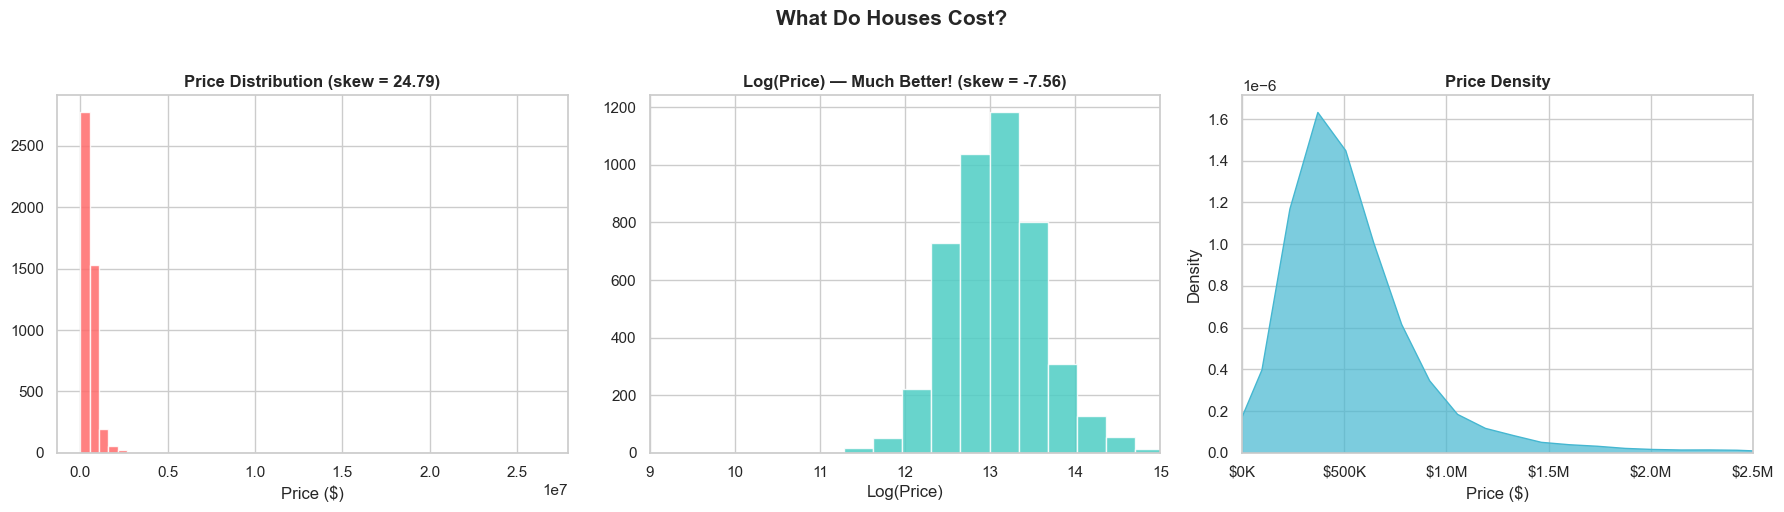

In [290]:
import matplotlib.ticker as ticker
def fmt_price(x, pos):
    if x >= 1_000_000:
        return f'${x/1_000_000:.1f}M'
    else:
        return f'${x/1000:.0f}K'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(df['price'], bins=50, edgecolor='white', alpha=0.85, color='#FF6B6B')
axes[0].set_title(f'Price Distribution (skew = {df["price"].skew():.2f})')
axes[0].set_xlabel('Price ($)')
axes[1].hist(np.log1p(df['price']), bins=50, edgecolor='white', alpha=0.85, color='#4ECDC4')
axes[1].set_title(f'Log(Price) — Much Better! (skew = {np.log1p(df["price"]).skew():.2f})')
axes[1].set_xlabel('Log(Price)')
axes[1].set_xlabel('Log(Price)')
axes[1].set_xlim(9, 15)
sns.kdeplot(data=df, x='price', fill=True, ax=axes[2], color='#45B7D1', alpha=0.7)
axes[2].set_title('Price Density')
axes[2].set_xlabel('Price ($)')
axes[2].set_xlim(0, 2_500_000)  
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(fmt_price))
plt.suptitle('What Do Houses Cost?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Left Side - Price Distribution:

The blue histogram shows actual house prices

Skewness = 24.79 → Extremely right-skewed (most houses cluster at low prices, few very expensive outliers stretch the tail)

# Right Side - Log(Price) Distribution:

The green light curve shows the density of log-transformed prices

Skewness = -7.56 → Much closer to normal distribution (negative skew is significantly better than extreme positive skew)

The raw price distribution is heavily right-skewed — most houses cluster **under $500K**, but a few expensive ones stretch the tail. After log-transforming, the distribution looks nearly normal. We'll use this as our target variable for modeling

## our features look like?

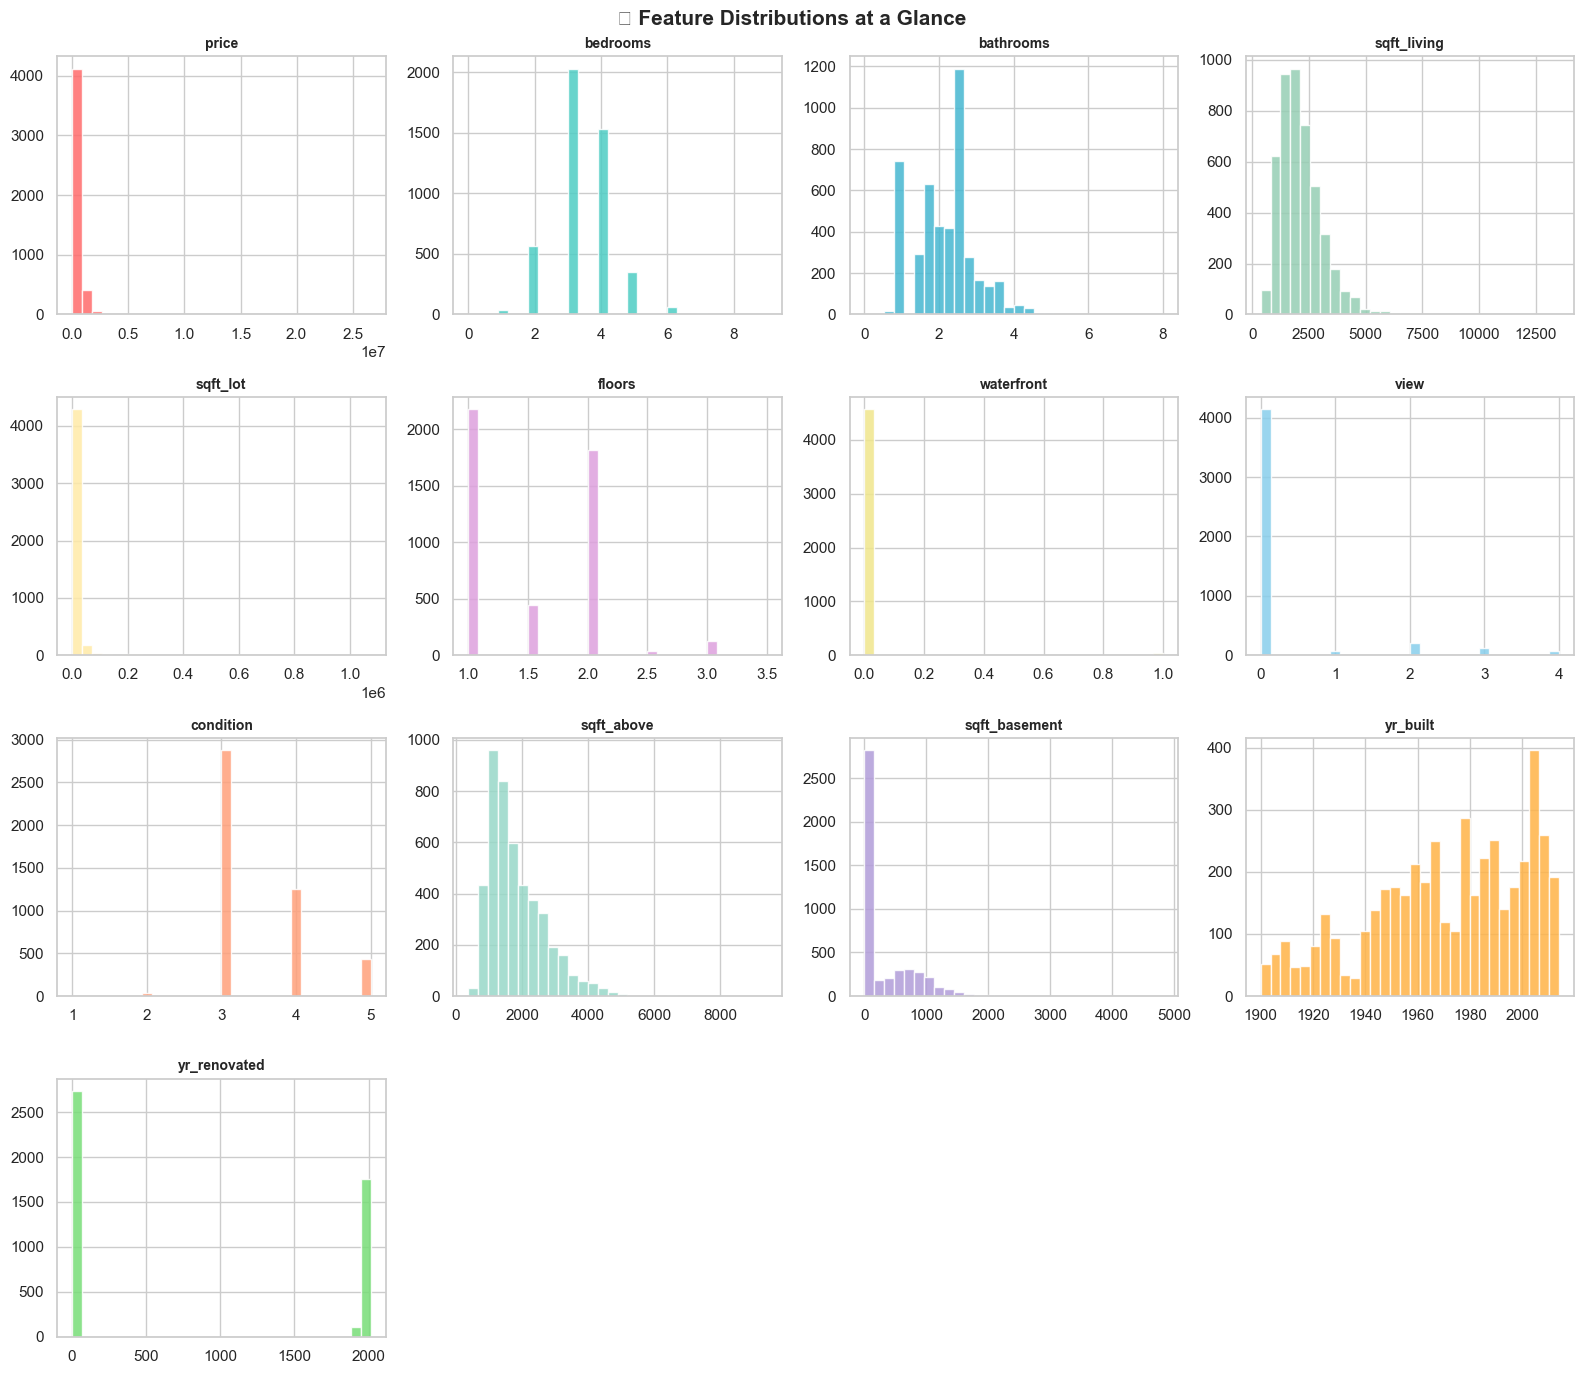

In [291]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
rows = (n + 3) // 4

fig, axes = plt.subplots(rows, 4, figsize=(16, 3.5 * rows))
axes = axes.flatten()

palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#F0E68C',
           '#87CEEB', '#FFA07A', '#98D8C8', '#B19CD9', '#FFB347', '#77DD77', '#FF6961']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', alpha=0.85, color=palette[i % len(palette)])
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('📊 Feature Distributions at a Glance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Violin plots show both the distribution shape and key statistics — they're like box plots but way more informative.**

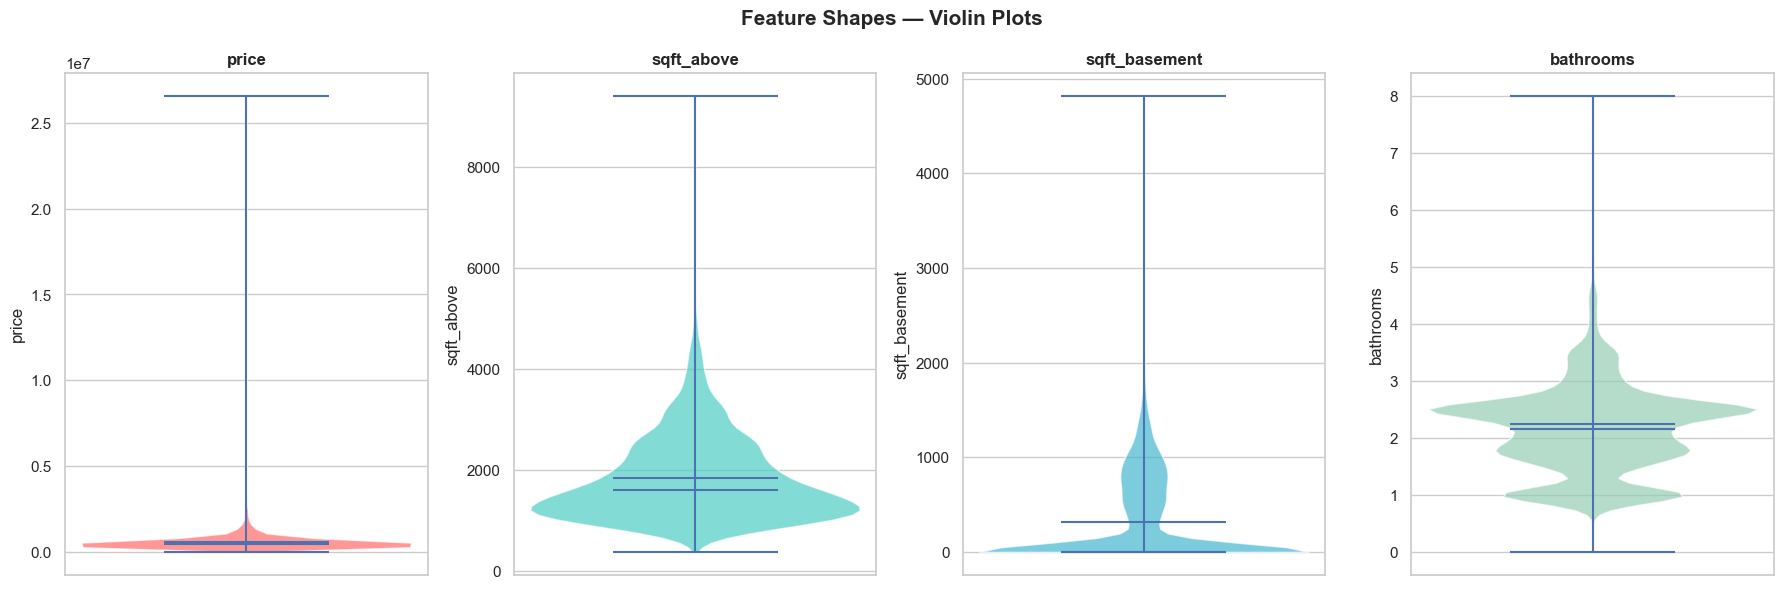

In [292]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, col in enumerate(['price', 'sqft_above', 'sqft_basement', 'bathrooms']):
    parts = axes[i].violinplot(df[col].dropna(), showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(palette[i])
        pc.set_alpha(0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])
plt.suptitle('Feature Shapes — Violin Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

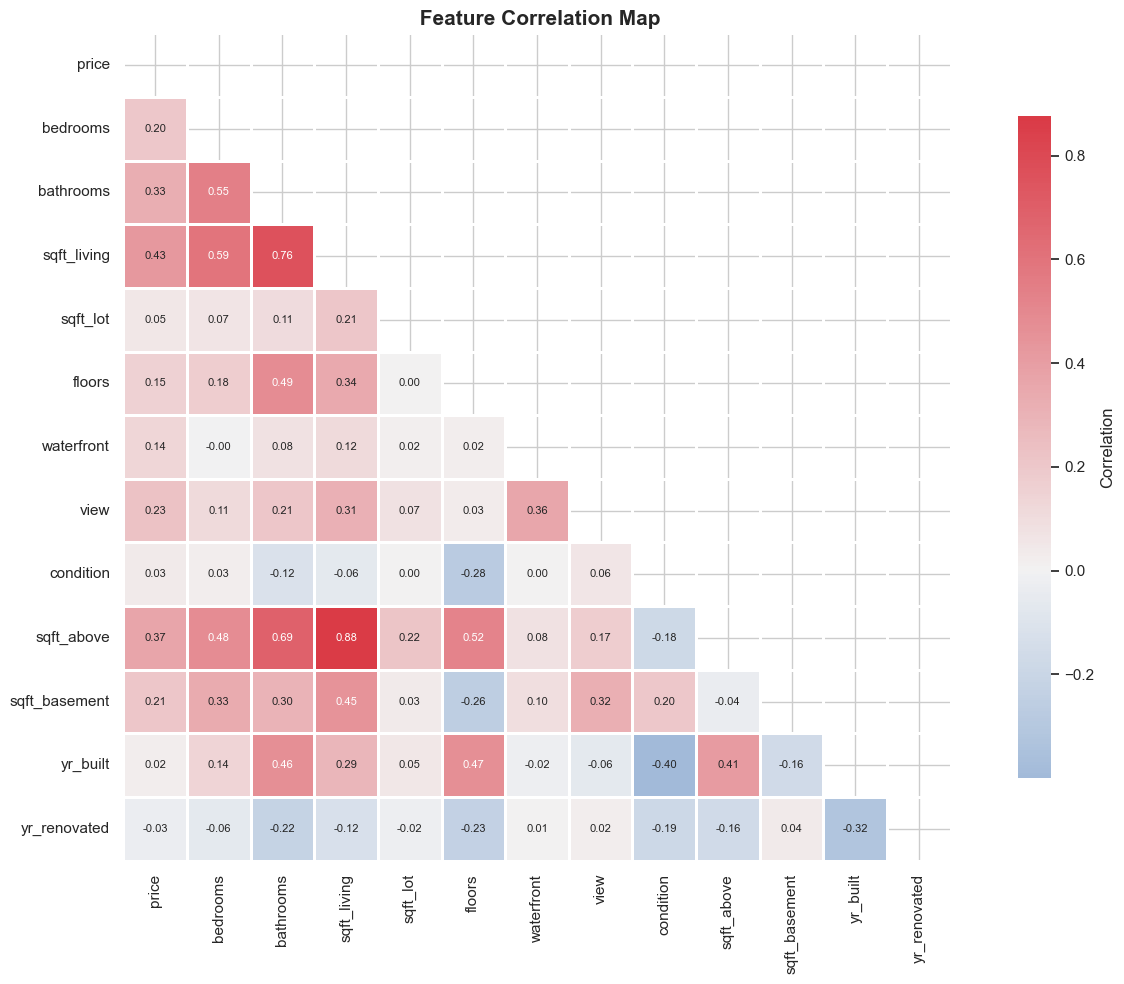

In [293]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.8, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 8})
plt.title(' Feature Correlation Map', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

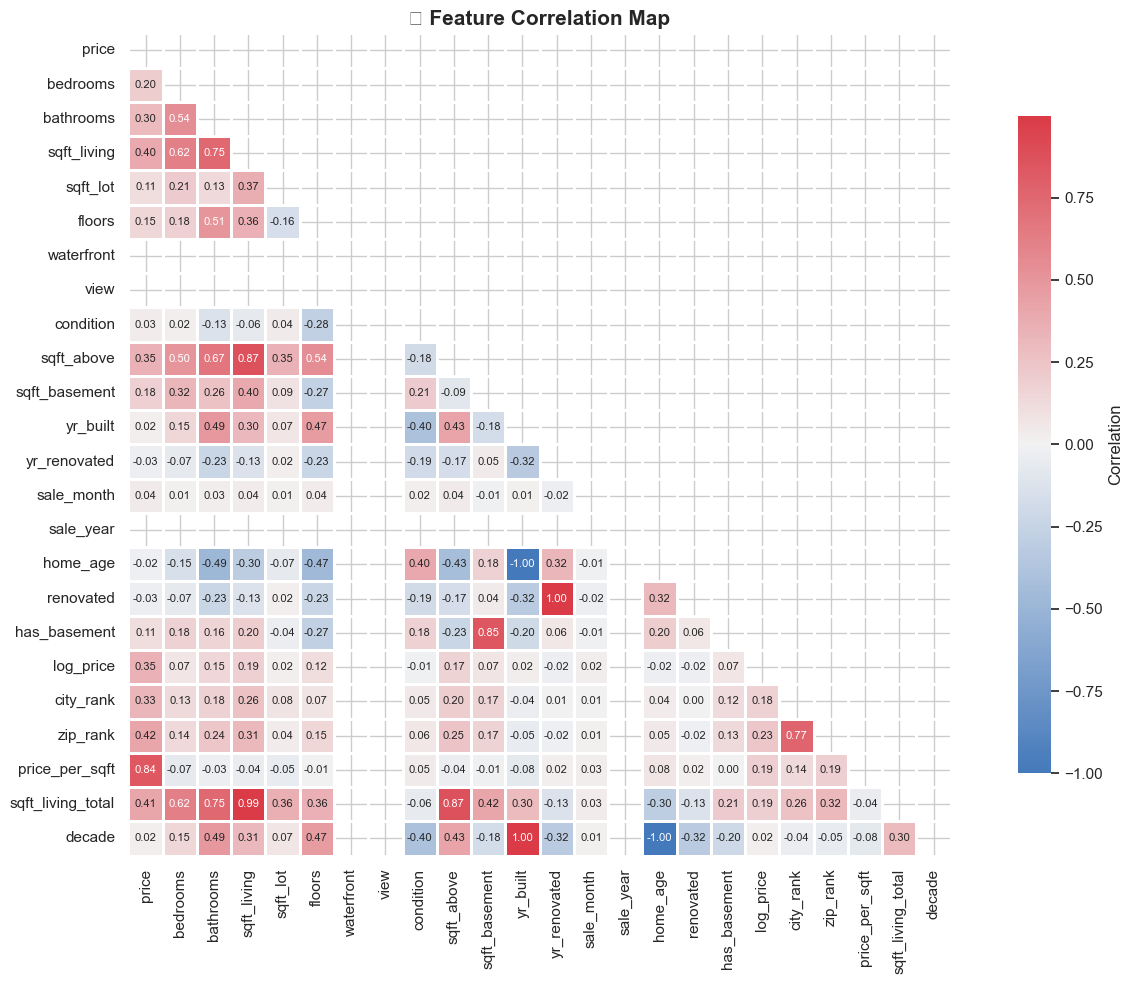

In [294]:
corr = df_new.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.8, cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 8})
plt.title('🔗 Feature Correlation Map', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Obeservations
sqft_living and sqft_above are highly correlated (~0.88) — makes sense since sqft_living = sqft_above + sqft_basement
bathrooms has a solid correlation with price (~0.43)**


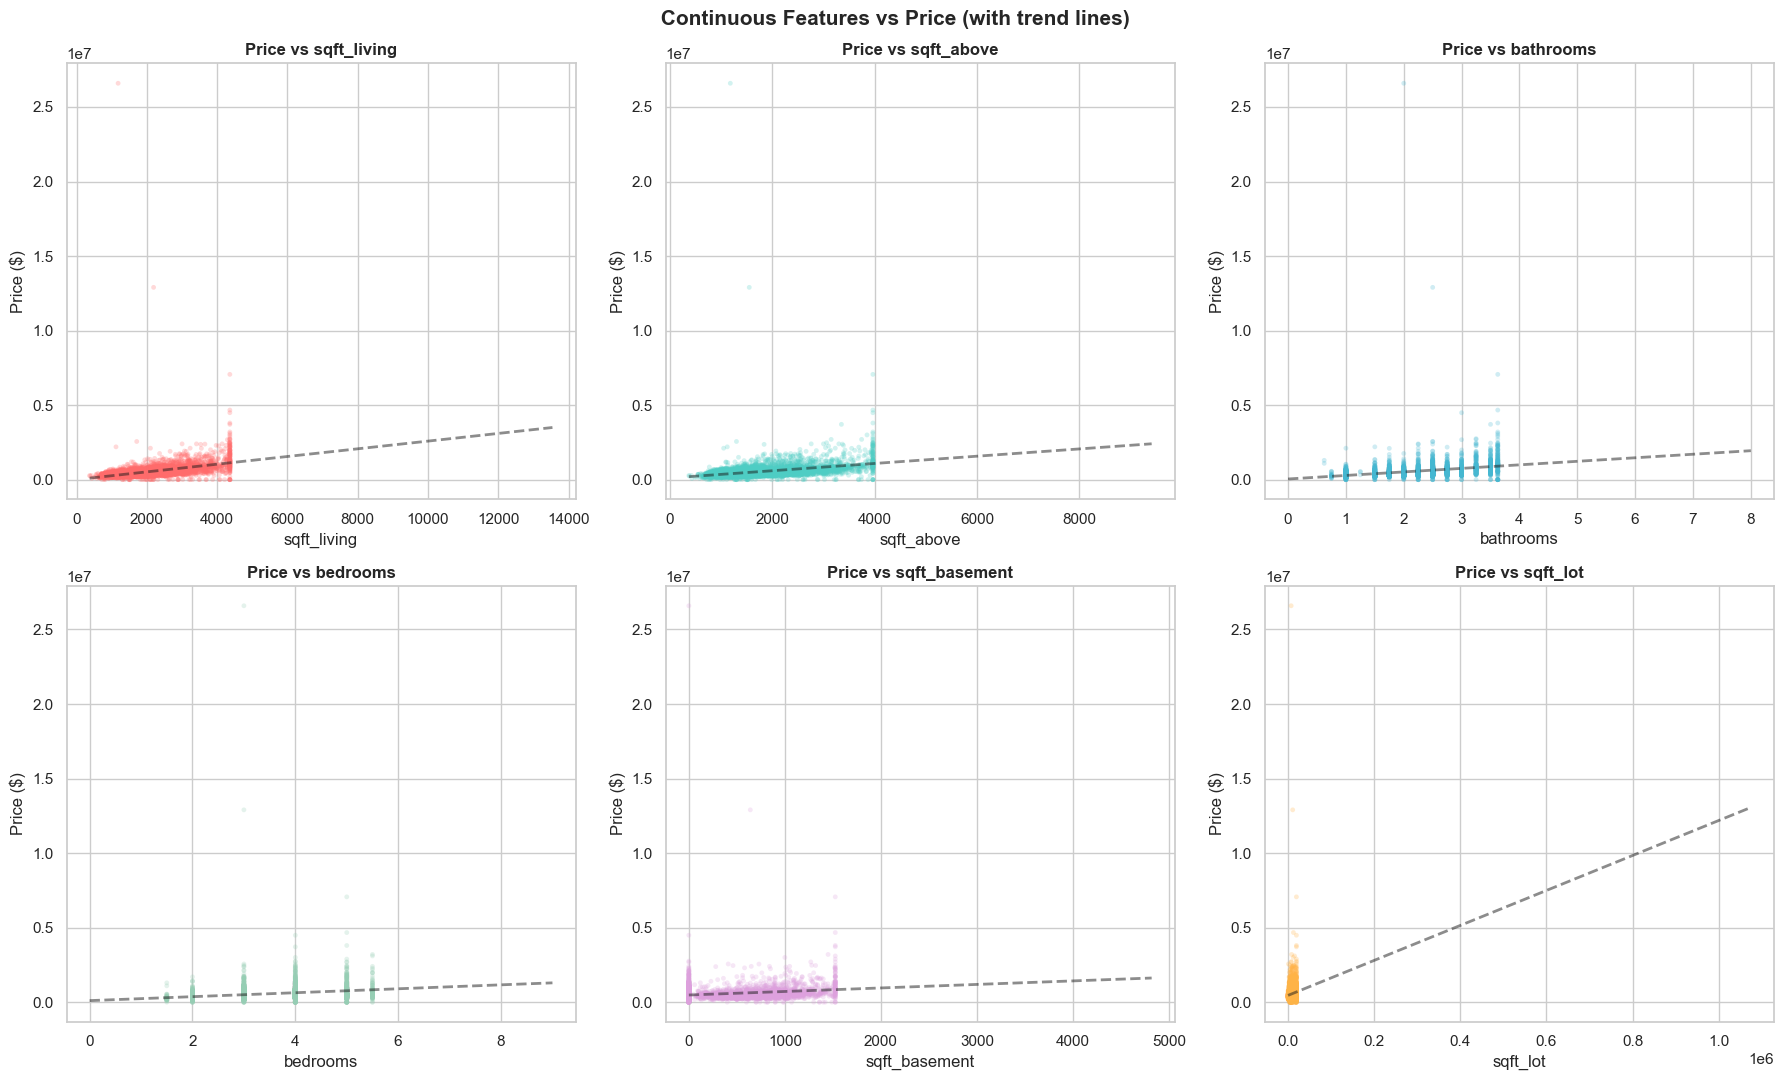

In [295]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

scatter_features = ['sqft_living', 'sqft_above', 'bathrooms', 'bedrooms', 'sqft_basement', 'sqft_lot']
scatter_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#DDA0DD', '#FFB347']

for i, (col, color) in enumerate(zip(scatter_features, scatter_colors)):
    axes[i].scatter(df_new[col], df_new['price'], alpha=0.25, s=12, color=color, edgecolors='none')
    z = np.polyfit(df_new[col], df_new['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=2)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'Price vs {col}')

plt.suptitle(' Continuous Features vs Price (with trend lines)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Key Observations

Feature	Relationship with Price	Interpretation
sqft_living	Strong positive correlation	Larger living spaces consistently command higher prices. Clear upward trend.

sqft_above	Strong positive correlation	Above-ground square footage is a major price driver. Similar pattern to total living space.

sqft_basement	Weak positive correlation	Basements add some value but with high variance. Many zero-basement homes still sell well.

sqft_lot	Very weak correlation	Lot size alone doesn't strongly predict price. A large plot doesn't guarantee high value.

bedrooms	Moderate positive correlation	More bedrooms generally mean higher price, but diminishing returns after 4-5 bedrooms.

bathrooms	Moderate positive correlation	Bathroom count correlates with price, often reflecting overall house size/quality.

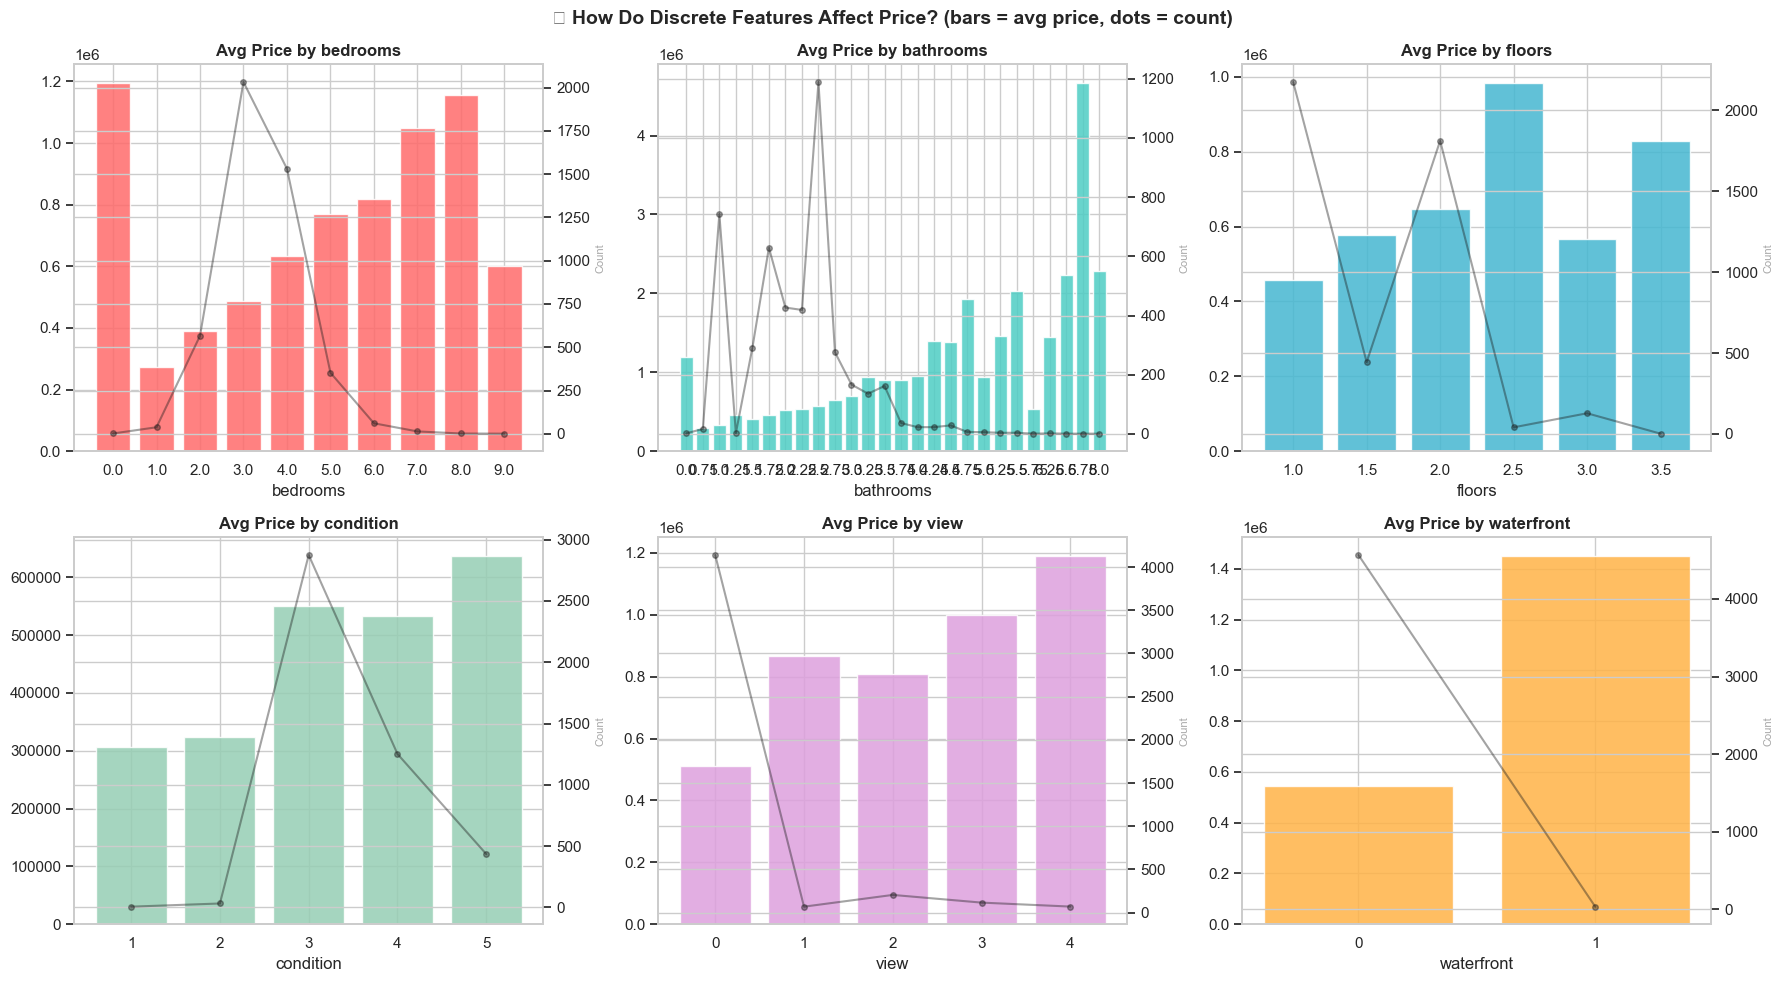

In [296]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cats = ['bedrooms', 'bathrooms', 'floors', 'condition', 'view', 'waterfront']
cat_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#DDA0DD', '#FFB347']

for i, (col, color) in enumerate(zip(cats, cat_colors)):
    grouped = df.groupby(col)['price'].agg(['mean', 'count']).reset_index()
    bars = axes[i].bar(grouped[col].astype(str), grouped['mean'], color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Avg Price by {col}')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)
    
    ax2 = axes[i].twinx()
    ax2.plot(grouped[col].astype(str), grouped['count'], 'ko-', markersize=4, alpha=0.4)
    ax2.set_ylabel('Count', fontsize=8, alpha=0.4)

plt.suptitle('📊 How Do Discrete Features Affect Price? (bars = avg price, dots = count)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Interesting findings:

Waterfront houses are dramatically more expensive (nearly 2x!)

View has a clear positive effect on price

More bathrooms → higher price (up to a point)

Bedrooms beyond 5-6 don't add much value — unusual layouts maybe?

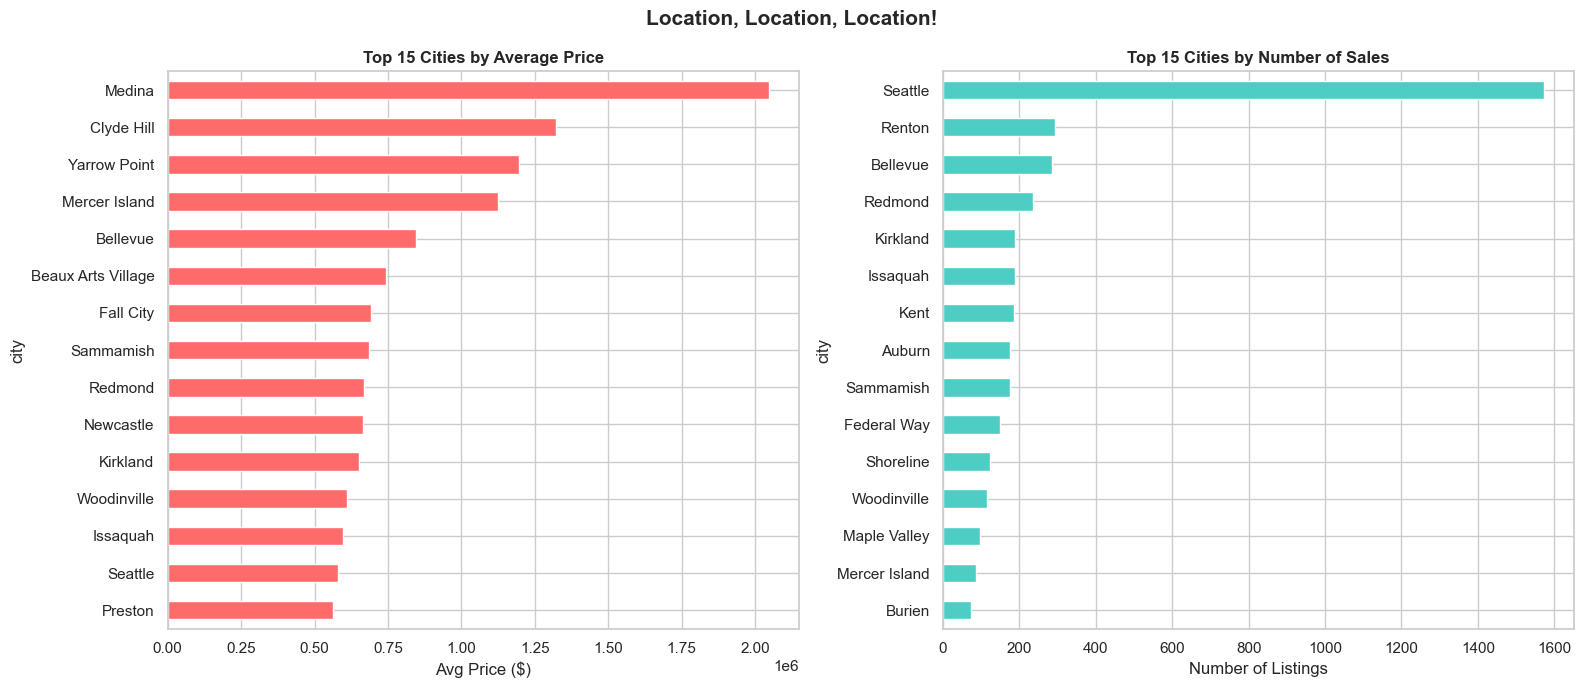

In [297]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_cities_price = df.groupby('city')['price'].mean().sort_values(ascending=False).head(15)
top_cities_price.plot(kind='barh', ax=axes[0], color='#FF6B6B', edgecolor='white')
axes[0].set_title('Top 15 Cities by Average Price')
axes[0].set_xlabel('Avg Price ($)')
axes[0].invert_yaxis()

top_cities_count = df['city'].value_counts().head(15)
top_cities_count.plot(kind='barh', ax=axes[1], color='#4ECDC4', edgecolor='white')
axes[1].set_title('Top 15 Cities by Number of Sales')
axes[1].set_xlabel('Number of Listings')
axes[1].invert_yaxis()

plt.suptitle('Location, Location, Location!', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [298]:
def plot_categorical(data, col, top_n=15):
    s = data[col].astype(str).fillna("Missing")
    vc = s.value_counts()

    top_vc = vc.head(top_n)

    s_plot = s[s.isin(top_vc.index)]
    order = top_vc.index.tolist()

    counts = top_vc

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.countplot(
        y=s_plot,
        order=order,
        hue=s_plot,
        palette="Set2",
        ax=axes[0],
        legend=False
    )
    axes[0].set_title(f"Count Plot: {col}")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel(col)

    
    axes[1].pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False
    )
    axes[1].set_title(f"Distribution: {col}")
    axes[1].axis("equal")

    plt.tight_layout()
    plt.show()


    plt.tight_layout()
    plt.show()

In [299]:
sns.set_theme(style="whitegrid")

df_plot = df.copy()

categorical_cols = []
numerical_cols = []

for col in df_plot.columns:
    if col in ["date", "price"]:
        continue

    nunique = df_plot[col].nunique(dropna=True)
    is_numeric = pd.api.types.is_numeric_dtype(df_plot[col])

    if (not is_numeric) or (is_numeric and nunique < 30):
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

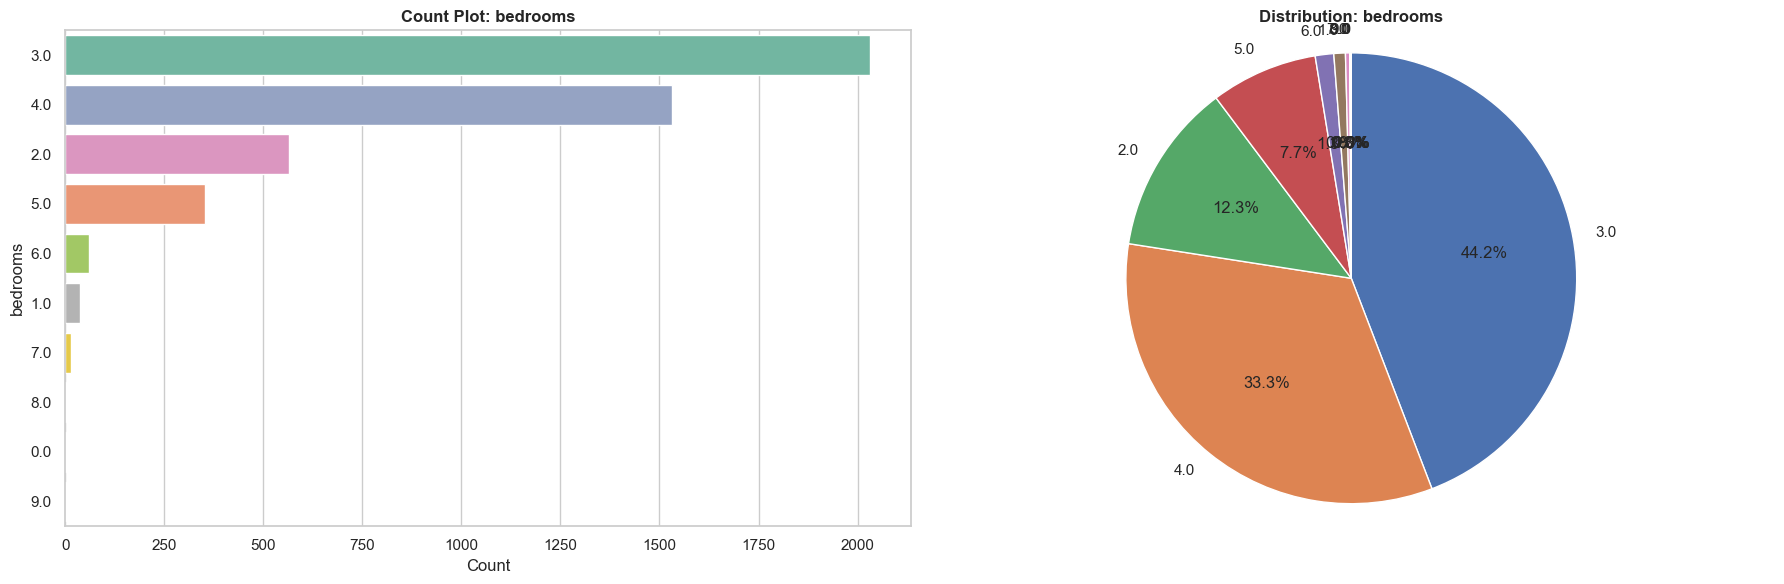

<Figure size 1400x600 with 0 Axes>

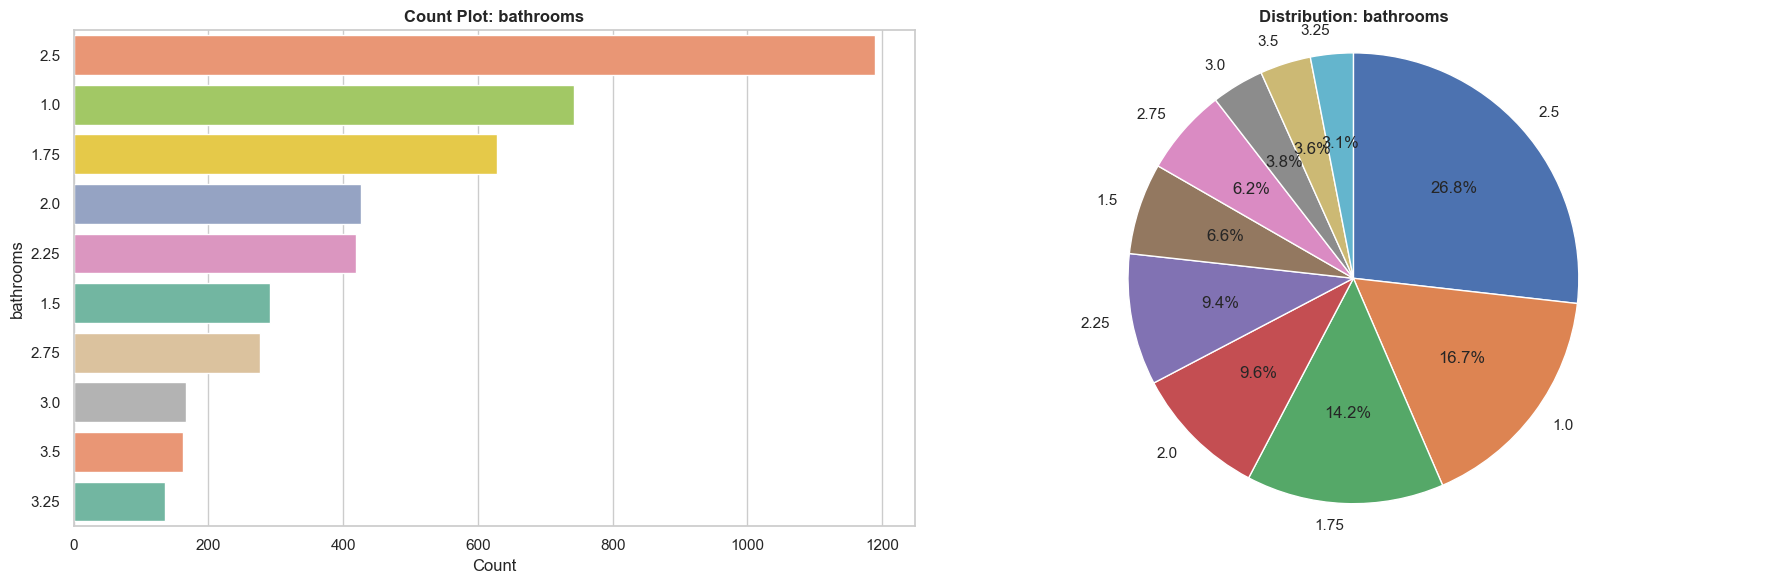

<Figure size 1400x600 with 0 Axes>

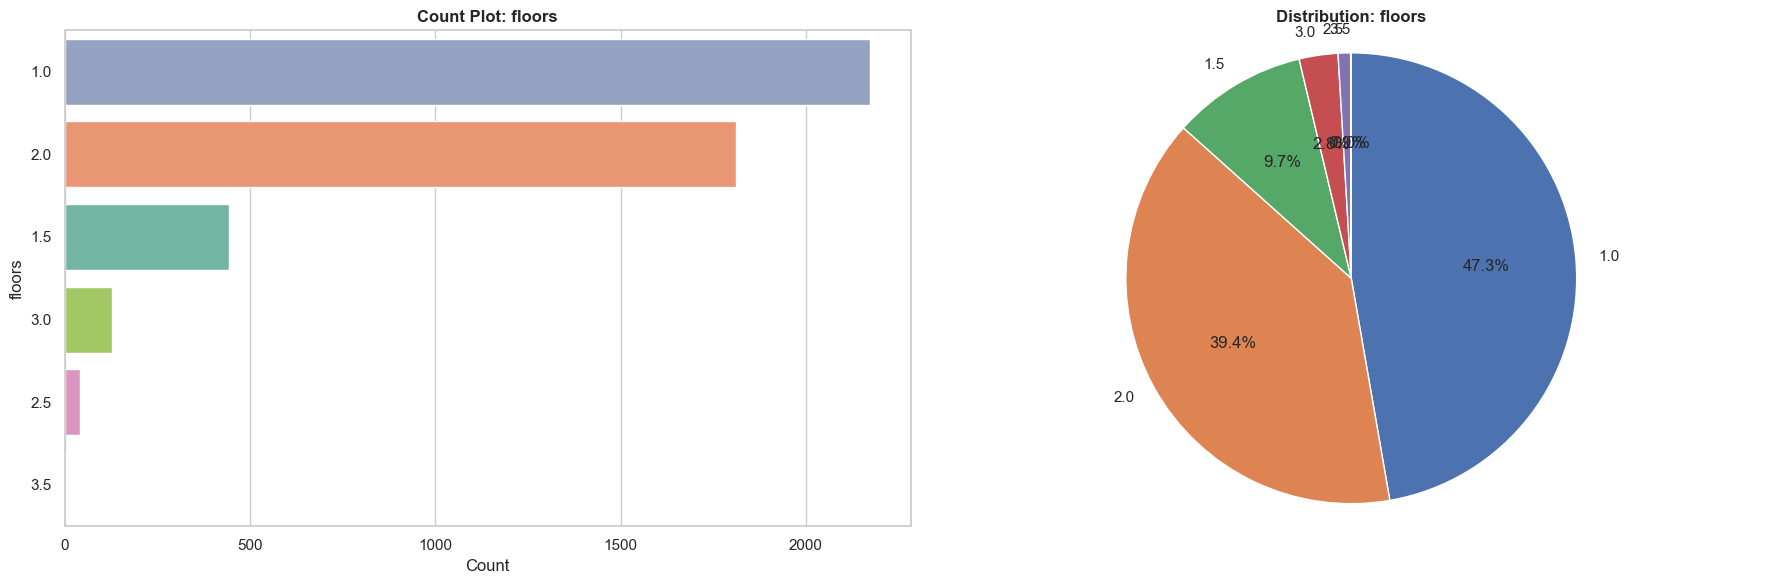

<Figure size 1400x600 with 0 Axes>

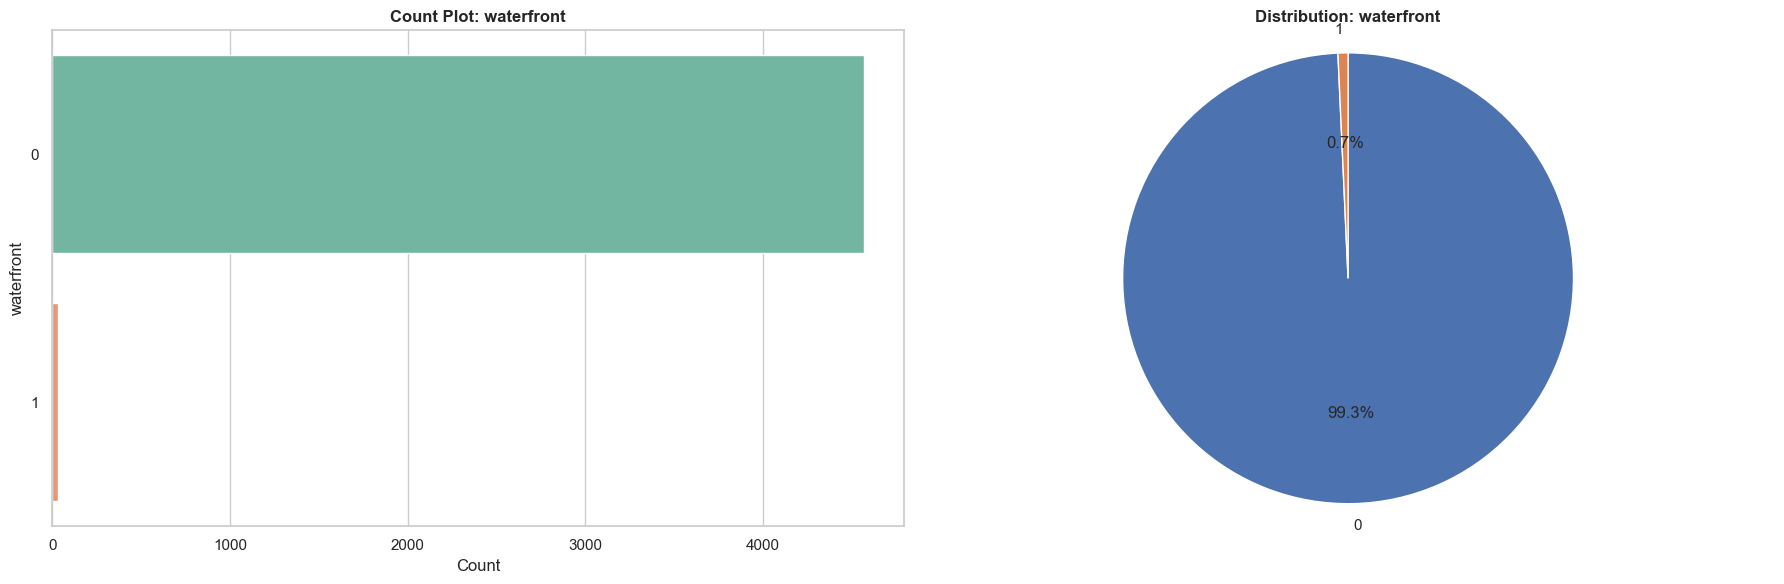

<Figure size 1400x600 with 0 Axes>

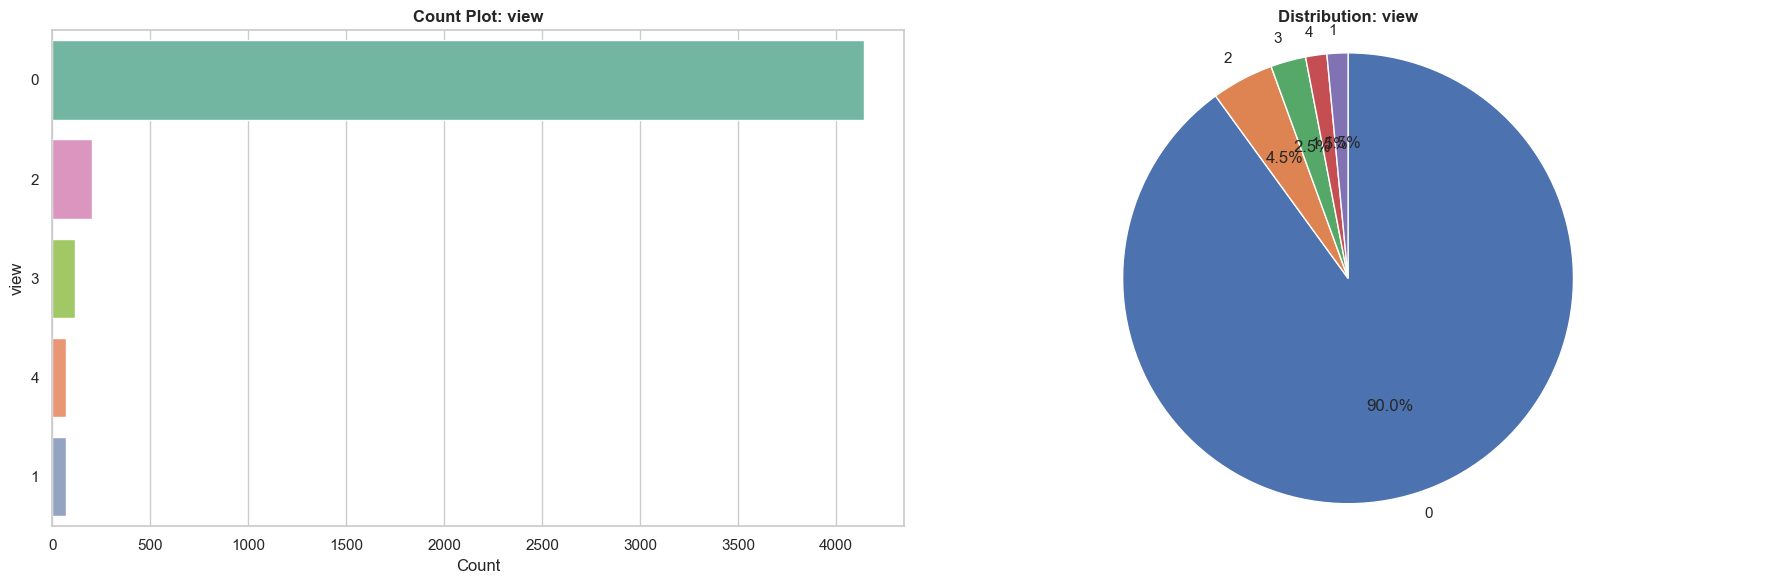

<Figure size 1400x600 with 0 Axes>

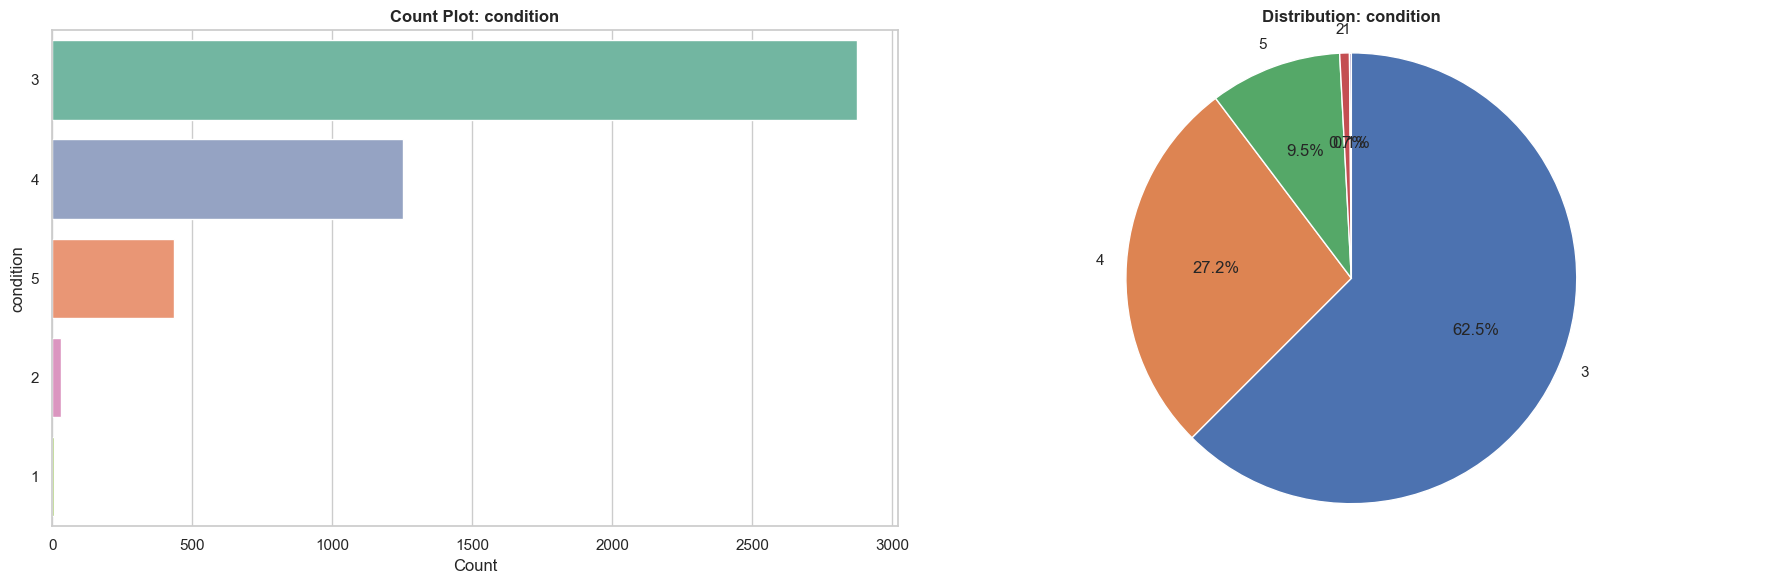

<Figure size 1400x600 with 0 Axes>

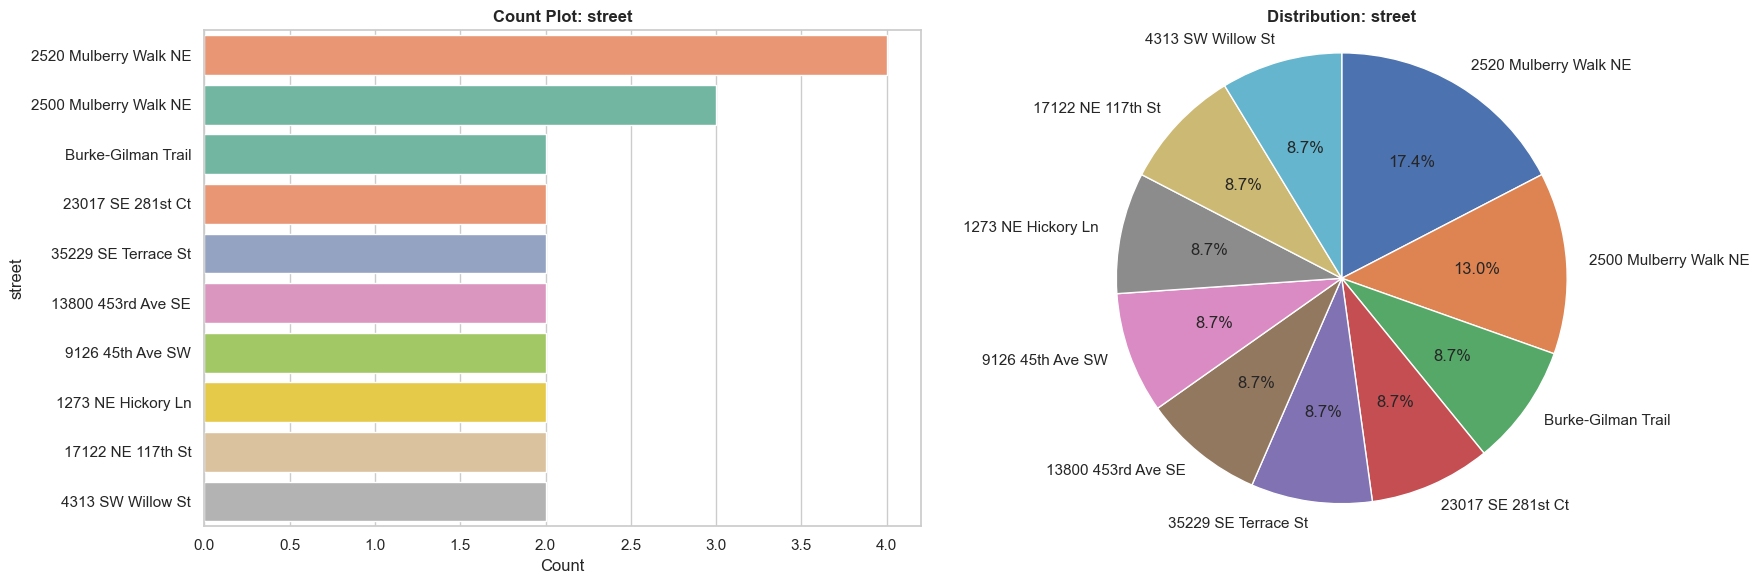

<Figure size 1400x600 with 0 Axes>

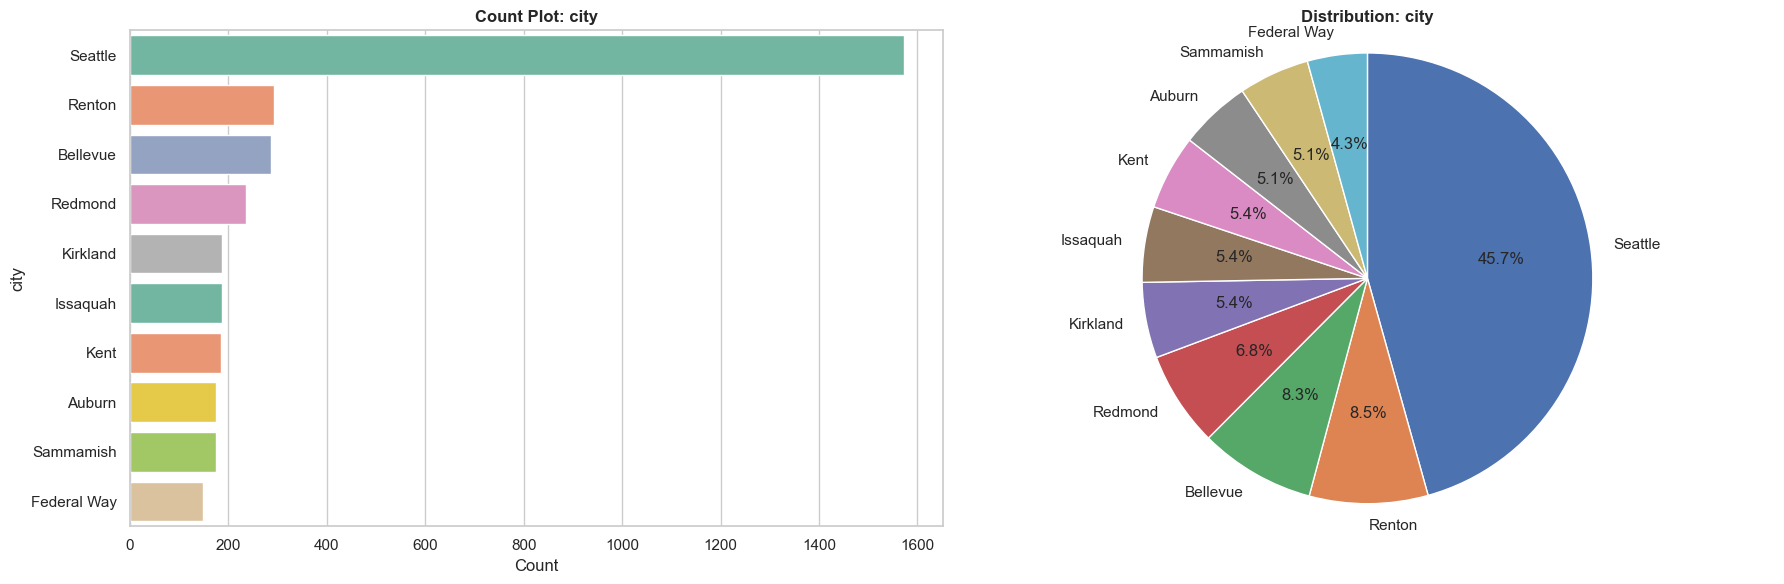

<Figure size 1400x600 with 0 Axes>

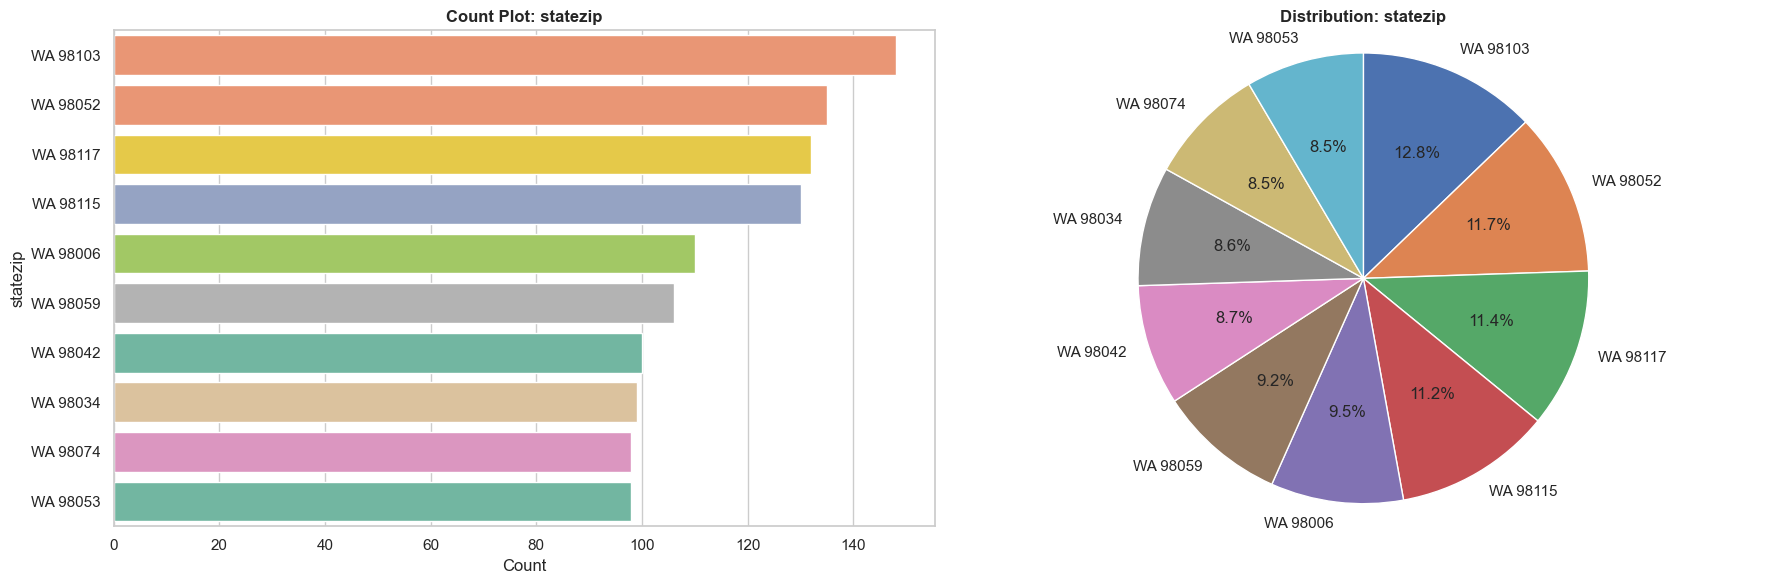

<Figure size 1400x600 with 0 Axes>

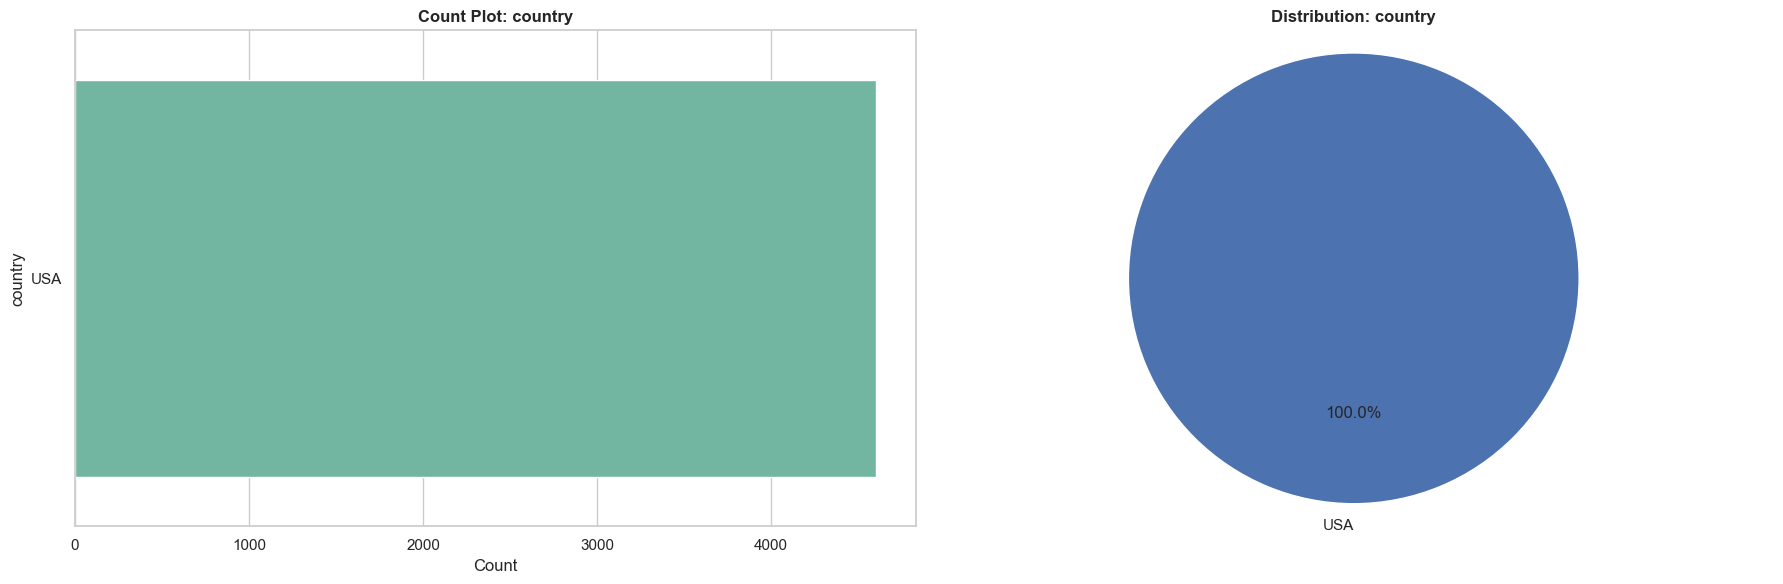

<Figure size 1400x600 with 0 Axes>

In [300]:
for col in categorical_cols:
    plot_categorical(df_plot, col, top_n=10)

## Stage 3 Unsupervised Learning (Clustering)

In [301]:
df_new.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country', 'sale_month', 'sale_year', 'home_age',
       'renovated', 'has_basement', 'log_price', 'city_rank', 'zip_rank',
       'price_per_sqft', 'sqft_living_total', 'decade'],
      dtype='str')

🔹 Running Stage 3: Clustering...


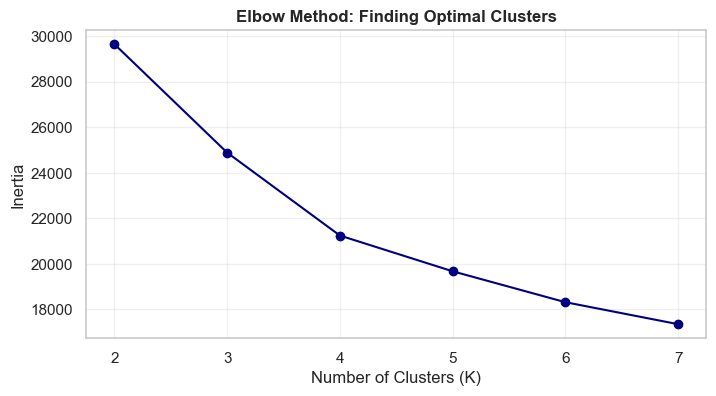


📊 Cluster Profile (Sorted by Price):

              price  sqft_living  home_age  view  bedrooms  bathrooms
cluster                                                              
6         370564.60      1192.46     74.98   0.0      2.52       1.17
3         433527.30      1824.98     41.70   0.0      3.31       1.94
4         445490.38      1519.15     57.39   0.0      3.08       1.61
1         459425.26      1911.32     14.81   0.0      3.17       2.45
2         617921.49      2355.26     66.38   0.0      3.85       2.26
0         753316.74      3117.28     21.89   0.0      4.01       2.73
5        1072422.30      3694.95     33.35   0.0      4.42       3.20

🏷️ Cluster Labels Assigned: {'Large Family Homes', 'Upscale Properties', 'Luxury Estates', 'Starter Homes'}

✅ Clustering Complete.



In [372]:

CLUSTER_FEATURES = [
    'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors',
    'condition', 'waterfront', 'view', 'sqft_above', 'sqft_basement',
    'home_age' 
]


valid_cluster_features = [f for f in CLUSTER_FEATURES if f in df_new.columns]

def elbow_method(df, features):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    inertias = []
    k_range = range(2, 8)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    plt.figure(figsize=(8, 4))
    plt.plot(k_range, inertias, marker='o', color='navy')
    plt.title('Elbow Method: Finding Optimal Clusters')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Inertia')
    plt.grid(True, alpha=0.3)
    plt.show()

def apply_clustering(df, features, k=5):
    # Only use valid columns
    X = df[features]
    
    cluster_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init='auto'))
    ])
    
    cluster_pipe.fit(X)
    df['cluster'] = cluster_pipe.named_steps['kmeans'].labels_
    return df, cluster_pipe

def analyze_clusters(df):
    profile = df.groupby('cluster').agg({
        'price': 'mean',
        'sqft_living': 'mean',
        'home_age': 'mean',
        'view': 'mean',
        'bedrooms': 'mean',
        'bathrooms': 'mean'
    }).sort_values('price')
    
    print("\n📊 Cluster Profile (Sorted by Price):\n")
    print(profile.round(2))
    return profile

def label_clusters(df, profile):
    LABELS = {}
    price_q75 = profile['price'].quantile(0.75)
    price_q25 = profile['price'].quantile(0.25)

    for cluster in profile.index:
        price = profile.loc[cluster, 'price']
        sqft = profile.loc[cluster, 'sqft_living']

        if price >= price_q75:
            LABELS[cluster] = "Luxury Estates"
        elif price <= price_q25:
            LABELS[cluster] = "Starter Homes"
        elif sqft >= 2000 : 
            LABELS[cluster] = "Large Family Homes"
        else:
            LABELS[cluster] = "Upscale Properties"

    df['cluster_label'] = df['cluster'].map(LABELS)
    print("\n🏷️ Cluster Labels Assigned:", set(LABELS.values()))
    return df, LABELS


print("🔹 Running Stage 3: Clustering...")
elbow_method(df_new, valid_cluster_features)

best_k = 7 
df_new, cluster_model = apply_clustering(df_new, valid_cluster_features, k=best_k)
profile = analyze_clusters(df_new)
df_new, labels_dict = label_clusters(df_new, profile)

print("\n✅ Clustering Complete.\n")

In [304]:
df_new.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,renovated,has_basement,log_price,city_rank,zip_rank,price_per_sqft,sqft_living_total,decade,cluster,cluster_label
0,2014-05-02,313000.0,3.0,1.50,1340.0,7912.0,1.5,0,0,3.0,...,1,0,12.653962,420392.3750,374433.21875,233.582092,1340.0,1950,1,Starter Homes
1,2014-05-02,2384000.0,5.0,2.50,3650.0,9050.0,2.0,0,0,5.0,...,0,1,14.684291,579837.4375,914441.50000,653.150696,3650.0,1920,2,Luxury Estates
2,2014-05-02,342000.0,3.0,2.00,1930.0,11947.0,1.0,0,0,4.0,...,0,0,12.742569,439492.4375,320243.96875,177.202072,1930.0,1960,3,Starter Homes
3,2014-05-02,420000.0,3.0,2.25,2000.0,8030.0,1.0,0,0,4.0,...,0,1,12.948012,847180.6875,602963.12500,210.000000,2000.0,1960,2,Luxury Estates
4,2014-05-02,550000.0,4.0,2.50,1940.0,10500.0,1.0,0,0,4.0,...,1,1,13.217675,667649.5625,637555.75000,283.505157,1940.0,1970,2,Luxury Estates


## stage 4 Category Classification

In [352]:
df_new['cluster_label'].value_counts()

cluster_label
Large Family Homes    2146
Starter Homes         1604
Luxury Estates         850
Name: count, dtype: int64

🔹 Starting Stage 4: AI Category Classification...

🎯 Model Accuracy: 94.24%

📋 Classification Report:
                    precision    recall  f1-score   support

Large Family Homes       0.89      0.95      0.92       131
    Luxury Estates       0.98      0.93      0.95       210
     Starter Homes       0.95      0.95      0.95       265
Upscale Properties       0.94      0.94      0.94       314

          accuracy                           0.94       920
         macro avg       0.94      0.94      0.94       920
      weighted avg       0.94      0.94      0.94       920



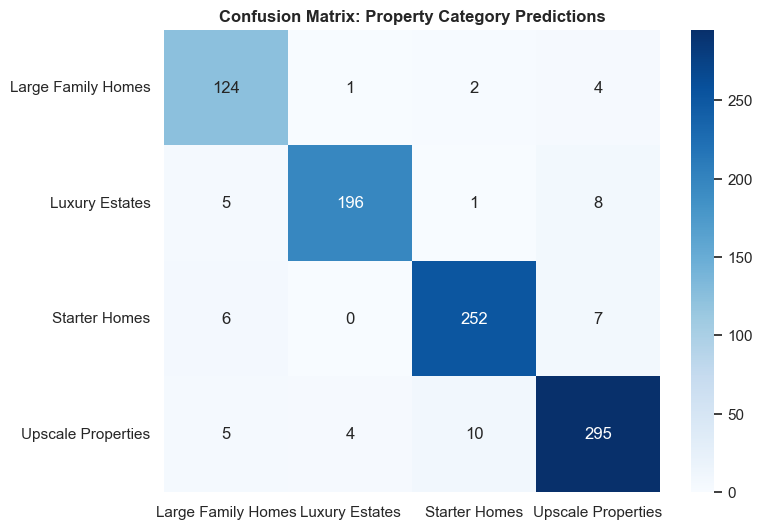

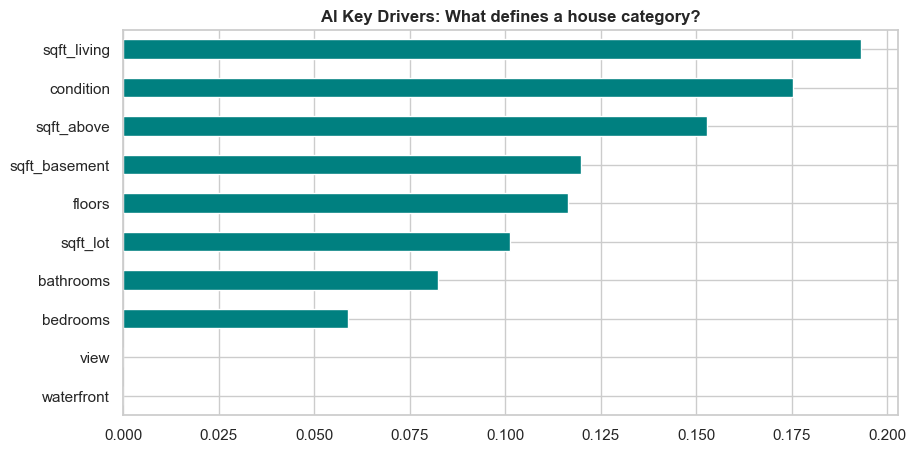

✅ Classifier Saved to 'models/category_classifier_pipeline.pkl'


In [373]:

CLASSIF_FEATURES = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'condition', 'waterfront', 'view', 'grade', 'sqft_above', 
    'sqft_basement', 'age' 
]

def train_property_classifier(df):
    print("🔹 Starting Stage 4: AI Category Classification...")
    
   
    valid_features = [f for f in CLASSIF_FEATURES if f in df.columns]
    X = df[valid_features]
    y = df['cluster_label']

    
    mask = y.notna()
    X, y = X[mask], y[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    
    clf_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
    ])

    # Train
    clf_pipe.fit(X_train, y_train)
    y_pred = clf_pipe.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print(f"\n🎯 Model Accuracy: {acc:.2%}")
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Visualizations
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.title('Confusion Matrix: Property Category Predictions')
    plt.show()

    # Feature Importance
    importances = clf_pipe.named_steps['clf'].feature_importances_
    plt.figure(figsize=(10, 5))
    pd.Series(importances, index=valid_features).sort_values().plot(kind='barh', color='teal')
    plt.title('AI Key Drivers: What defines a house category?')
    plt.show()

    # Save Model
    os.makedirs("models", exist_ok=True)
    joblib.dump(clf_pipe, 'models/category_classifier_pipeline.pkl')
    print("✅ Classifier Saved to 'models/category_classifier_pipeline.pkl'")
    
    return clf_pipe


classifier_model = train_property_classifier(df_new)

## Stage 5 Price Regression Modeling

In [369]:
df_new.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,renovated,has_basement,log_price,city_rank,zip_rank,price_per_sqft,sqft_living_total,decade,cluster,cluster_label
0,2014-05-02,313000.0,3.0,1.50,1340.0,7912.0,1.5,0,0,3.0,...,1,0,12.653962,420392.364047,374433.21875,233.582092,1340.0,1950,6,Starter Homes
1,2014-05-02,2384000.0,5.0,2.50,3650.0,9050.0,2.0,0,0,5.0,...,0,1,14.684291,579837.467282,914441.50000,653.150696,3650.0,1920,0,Luxury Estates
2,2014-05-02,342000.0,3.0,2.00,1930.0,11947.0,1.0,0,0,4.0,...,0,0,12.742569,439492.444648,320243.96875,177.202072,1930.0,1960,4,Upscale Properties
3,2014-05-02,420000.0,3.0,2.25,2000.0,8030.0,1.0,0,0,4.0,...,0,1,12.948012,847180.662995,602963.12500,210.000000,2000.0,1960,2,Large Family Homes
4,2014-05-02,550000.0,4.0,2.50,1940.0,10500.0,1.0,0,0,4.0,...,1,1,13.217675,667649.534781,637555.75000,283.505157,1940.0,1970,2,Large Family Homes


**Data Preprocessing**

In [382]:

print("📦 Preparing data for high-accuracy regression...")

q_limit = df_new['price'].quantile(0.98)
df_reg = df_new[(df_new['price'] > 0) & (df_new['price'] < q_limit)].copy()

if 'statezip' in df_reg.columns:
    zip_means = df_reg.groupby('statezip')['log_price'].mean()
    df_reg['zip_rank'] = df_reg['statezip'].map(zip_means)

REG_FEATURES = [
    'sqft_living', 'sqft_lot', 'bathrooms', 'bedrooms', 'view', 
    'zip_rank',    
    'home_age',     
    'waterfront', 'condition', 'sqft_above', 'renovated', 'floors',
    'city_rank', 'has_basement'
]

X = df_reg[REG_FEATURES].fillna(df_reg[REG_FEATURES].median())
y = df_reg['log_price']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"✅ Preprocessing complete: {len(df_reg)} samples.")




📦 Preparing data for high-accuracy regression...
✅ Preprocessing complete: 4459 samples.


In [384]:
X

,sqft_living,sqft_lot,bathrooms,bedrooms,view,zip_rank,home_age,waterfront,condition,sqft_above,renovated,floors,city_rank,has_basement
0,1340.0,7912.0,1.50,3.0,0,12.802350,59,0,3.0,1340.0,1,1.5,420392.364047,0
2,1930.0,11947.0,2.00,3.0,0,12.574005,48,0,4.0,1930.0,0,1.0,439492.444648,0
3,2000.0,8030.0,2.25,3.0,0,13.223434,51,0,4.0,1000.0,0,1.0,847180.662995,1
4,1940.0,10500.0,2.50,4.0,0,13.318765,38,0,4.0,1140.0,1,1.0,667649.534781,1
5,880.0,6380.0,1.00,2.0,0,13.241468,76,0,3.0,880.0,1,1.0,579837.467282,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,1510.0,6360.0,1.75,3.0,0,12.802350,60,0,4.0,1510.0,1,1.0,579837.467282,0
4596,1460.0,7573.0,2.50,3.0,0,13.340477,31,0,3.0,1460.0,1,2.0,847180.662995,0
4597,3010.0,7014.0,2.50,3.0,0,13.049143,5,0,3.0,3010.0,0,2.0,377040.966329,0
4598,2090.0,6630.0,2.00,4.0,0,12.467816,40,0,3.0,1070.0,0,1.0,579837.467282,1


In [385]:
y

0       12.653962
2       12.742569
3       12.948012
4       13.217675
5       13.102162
          ...    
4595    12.638399
4596    13.188777
4597    12.940614
4598    12.222935
4599    12.304111
Name: log_price, Length: 4459, dtype: float32

In [ ]:
def eval_reg(name, pipe, Xtr, Xte, ytr, yte):
        pipe.fit(Xtr, ytr)
        pred = np.expm1(pipe.predict(Xte))
        true = np.expm1(yte)
        return {'Model': name,
                'MAE':  mean_absolute_error(true, pred),
                'RMSE': np.sqrt(mean_squared_error(true, pred)),
                'R²':   r2_score(true, pred),
                'MAPE': np.mean(np.abs((true - pred) / true)) * 100,
                '_pipe': pipe, '_pred': pred, '_true': true}

def make_pipe(model): return Pipeline([('imp', SimpleImputer(strategy='median')),
                                            ('sc',  StandardScaler()), ('reg', model)])

models = {
        'Linear Regression':     make_pipe(LinearRegression()),

        'Ridge': make_pipe(
            Ridge(alpha=10.0)
        ),

        
        'Random Forest': make_pipe(
            RandomForestRegressor(
                n_estimators   = 500,
                max_depth      = None,       
                min_samples_leaf = 2,
                max_features   = 0.5,        
                random_state   = 42,
                n_jobs         = -1,
            )
        ),

    
        'Gradient Boosting': make_pipe(
            GradientBoostingRegressor(
                n_estimators   = 500,
                learning_rate  = 0.05,      
                max_depth      = 4,          
                subsample      = 0.8,
                min_samples_leaf = 5,
                max_features   = 0.7,
                random_state   = 42,
            )
        ),

        
    }

results = [eval_reg(name, pipe, X_tr, X_te, y_tr, y_te) for name, pipe in models.items()]
results_df = pd.DataFrame(results).drop(columns=['_pipe','_pred','_true'])
results_df.set_index('Model').style.highlight_min(['MAE','RMSE','MAPE'], color='#4CAF50') \
                                    .highlight_max(['R²'], color='#4CAF50').format(
        {'MAE': '${:,.0f}', 'RMSE': '${:,.0f}', 'R²': '{:.4f}', 'MAPE': '{:.1f}%'})

,MAE,RMSE,R²,MAPE
Model,,,,
Linear Regression,"$91,524","$143,540",0.7219,19.0%
Ridge,"$91,496","$143,561",0.7218,19.0%
Random Forest,"$81,847","$132,433",0.7632,16.7%
Gradient Boosting,"$80,483","$131,310",0.7672,16.7%


In [ ]:
best_result = max(results, key=lambda x: x['R²'])
best_model_name = best_result['Model']
best_pipeline = best_result['_pipe']  

print(f"🥇 Winner: {best_model_name}")
print(f"   • R² Score: {best_result['R²']:.4f}")
print(f"   • MAPE: {best_result['MAPE']:.1f}%")
print(f"   • Average Error: ${best_result['MAE']:,.0f}")


os.makedirs("models", exist_ok=True)


best_model_path = "models/best_house_price_predictor.pkl"
joblib.dump(best_pipeline, best_model_path)
print(f"\n✅ Best model pipeline saved to: {best_model_path}")

🥇 Winner: Gradient Boosting
   • R² Score: 0.7672
   • MAPE: 16.7%
   • Average Error: $80,483

✅ Best model pipeline saved to: models/best_house_price_predictor.pkl
